# 02_clean_occurrences.ipynb

GBIF Darwin Core Archive cleaning workflow for ecological connectivity analysis.

This notebook:
- extracts DwC-A archives
- loads occurrence tables
- validates coordinates
- removes problematic records
- converts to GeoDataFrame
- exports GIS-ready layers for QGIS
- stores outputs in the project architecture


## Imports

In [1]:
import zipfile
from pathlib import Path

import pandas as pd
import geopandas as gpd
import numpy as np

from shapely.geometry import Point

import matplotlib.pyplot as plt


In [2]:
import folium
from folium.plugins import MarkerCluster
from IPython.display import display

## Project Paths

In [3]:
PROJECT_ROOT = Path.cwd().parent

RAW_GBIF = PROJECT_ROOT / 'data' / 'raw' / 'gbif'
INTERIM_GBIF = PROJECT_ROOT / 'data' / 'interim' / 'gbif'
PROCESSED_SPECIES = PROJECT_ROOT / 'data' / 'processed' / 'species'

INTERIM_GBIF.mkdir(parents=True, exist_ok=True)
PROCESSED_SPECIES.mkdir(parents=True, exist_ok=True)


In [7]:
# Change species here
SPECIES = 'Nicrophorus_vespillo'

ZIP_PATH = RAW_GBIF / f'{SPECIES}.zip'

EXTRACT_DIR = INTERIM_GBIF / SPECIES
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

print(ZIP_PATH)
print(EXTRACT_DIR)


/home/linda/Documents/myData/data-management/data/raw/gbif/Nicrophorus_vespillo.zip
/home/linda/Documents/myData/data-management/data/interim/gbif/Nicrophorus_vespillo


In [8]:
QA_DIR = PROJECT_ROOT / 'data' / 'qa' / SPECIES
QA_DIR.mkdir(parents=True, exist_ok=True)

removed_csv_path = QA_DIR / f'{SPECIES}_removed_records.csv'
review_geojson_path = QA_DIR / f'{SPECIES}_review_points.geojson'

## Extract Darwin Core Archive

In [9]:
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print('Archive extracted successfully.')


Archive extracted successfully.


## Inspect Extracted Files

In [10]:
list(EXTRACT_DIR.glob('*'))


[PosixPath('/home/linda/Documents/myData/data-management/data/interim/gbif/Nicrophorus_vespillo/rights.txt'),
 PosixPath('/home/linda/Documents/myData/data-management/data/interim/gbif/Nicrophorus_vespillo/meta.xml'),
 PosixPath('/home/linda/Documents/myData/data-management/data/interim/gbif/Nicrophorus_vespillo/multimedia.txt'),
 PosixPath('/home/linda/Documents/myData/data-management/data/interim/gbif/Nicrophorus_vespillo/verbatim.txt'),
 PosixPath('/home/linda/Documents/myData/data-management/data/interim/gbif/Nicrophorus_vespillo/citations.txt'),
 PosixPath('/home/linda/Documents/myData/data-management/data/interim/gbif/Nicrophorus_vespillo/occurrence.txt'),
 PosixPath('/home/linda/Documents/myData/data-management/data/interim/gbif/Nicrophorus_vespillo/metadata.xml'),
 PosixPath('/home/linda/Documents/myData/data-management/data/interim/gbif/Nicrophorus_vespillo/dataset')]

## Load Occurrence Table

In [11]:
occurrence_file = EXTRACT_DIR / 'occurrence.txt'

df = pd.read_csv(
    occurrence_file,
    sep='\t',
    low_memory=False
)

print(df.shape)
df.head()


(18, 230)


,gbifID,accessRights,bibliographicCitation,language,license,modified,publisher,references,rightsHolder,type,...,publishedByGbifRegion,level0Gid,level0Name,level1Gid,level1Name,level2Gid,level2Name,level3Gid,level3Name,iucnRedListCategory
0,6178503558,NaN,NaN,NaN,CC_BY_NC_4_0,2026-03-16T14:52:49Z,NaN,https://www.inaturalist.org/observations/34331...,mhm43,NaN,...,NORTH_AMERICA,PRT,Portugal,PRT.1_1,Aveiro,PRT.1.5_1,Aveiro,PRT.1.5.6_1,Glória,NaN
1,5827896471,NaN,NaN,NaN,CC_BY_NC_4_0,2025-09-04T12:54:56Z,NaN,https://www.inaturalist.org/observations/30522...,endornis,NaN,...,NORTH_AMERICA,PRT,Portugal,PRT.4_1,Braga,PRT.4.7_1,Fafe,PRT.4.7.27_1,Ribeiros,NaN
2,5230047378,NaN,NaN,NaN,CC_BY_NC_4_0,2025-07-20T09:28:06Z,NaN,https://www.inaturalist.org/observations/29700...,Charcos Companhia,NaN,...,EUROPE,PRT,Portugal,PRT.1_1,Aveiro,PRT.1.18_1,Vagos,PRT.1.18.1_1,Calvão,NaN
3,5154723113,NaN,NaN,NaN,CC_BY_NC_4_0,2025-05-01T14:43:43Z,NaN,https://www.inaturalist.org/observations/27487...,Beatriz Simões,NaN,...,NORTH_AMERICA,PRT,Portugal,PRT.7_1,Coimbra,PRT.7.2_1,Cantanhede,PRT.7.2.18_1,Tocha,NaN
4,4903933483,NaN,NaN,NaN,CC_BY_NC_4_0,2024-08-03T21:42:14Z,NaN,https://www.inaturalist.org/observations/22655...,Daniel,NaN,...,EUROPE,PRT,Portugal,PRT.15_1,Porto,PRT.15.9_1,Paços de Ferreira,PRT.15.9.8_1,Freamunde,NaN


## Keep Essential Columns

In [12]:
keep_cols = [
    'gbifID',
    'species',
    'decimalLatitude',
    'decimalLongitude',
    'countryCode',
    'eventDate',
    'basisOfRecord',
    'coordinateUncertaintyInMeters',
    'year',
    'month',
    'day'
]

df = df[keep_cols].copy()

print(df.shape)


(18, 11)


## Remove Missing Coordinates

In [13]:
df = df.dropna(
    subset=['decimalLatitude', 'decimalLongitude']
)

print(df.shape)


(18, 11)


## Convert Coordinates to Numeric

In [14]:
df['decimalLatitude'] = pd.to_numeric(
    df['decimalLatitude'],
    errors='coerce'
)

df['decimalLongitude'] = pd.to_numeric(
    df['decimalLongitude'],
    errors='coerce'
)

df = df.dropna(
    subset=['decimalLatitude', 'decimalLongitude']
)

print(df.shape)


(18, 11)


## Remove Invalid Coordinates

In [15]:
df = df[
    (df['decimalLatitude'] >= -90) &
    (df['decimalLatitude'] <= 90) &
    (df['decimalLongitude'] >= -180) &
    (df['decimalLongitude'] <= 180)
]

print(df.shape)


(18, 11)


## Remove Zero Coordinates

In [16]:
df = df[
    ~(
        (df['decimalLatitude'] == 0) &
        (df['decimalLongitude'] == 0)
    )
]

print(df.shape)


(18, 11)


## Remove Duplicate Occurrences

In [17]:
df = df.drop_duplicates(
    subset=[
        'species',
        'decimalLatitude',
        'decimalLongitude'
    ]
)

print(df.shape)


(18, 11)


## Filter Coordinate Uncertainty

In [18]:
df['coordinateUncertaintyInMeters'] = pd.to_numeric(
    df['coordinateUncertaintyInMeters'],
    errors='coerce'
)

MAX_UNCERTAINTY = 5000

df = df[
    (
        df['coordinateUncertaintyInMeters'].isna()
    ) |
    (
        df['coordinateUncertaintyInMeters'] <= MAX_UNCERTAINTY
    )
]

print(df.shape)


(13, 11)


## Convert to GeoDataFrame

In [19]:
geometry = [
    Point(xy)
    for xy in zip(
        df['decimalLongitude'],
        df['decimalLatitude']
    )
]

gdf = gpd.GeoDataFrame(
    df,
    geometry=geometry,
    crs='EPSG:4326'
)

print(gdf.shape)
gdf.head()


(13, 12)


,gbifID,species,decimalLatitude,decimalLongitude,countryCode,eventDate,basisOfRecord,coordinateUncertaintyInMeters,year,month,day,geometry
0,6178503558,Nicrophorus vespillo,40.630628,-8.649583,PT,2026-03-16T12:34:01Z,HUMAN_OBSERVATION,NaN,2026,3,16,POINT (-8.64958 40.63063)
1,5827896471,Nicrophorus vespillo,41.495084,-8.112583,PT,2025-08-08T18:19:27,HUMAN_OBSERVATION,3361.0,2025,8,8,POINT (-8.11258 41.49508)
2,5230047378,Nicrophorus vespillo,40.490405,-8.686626,PT,2025-07-11T13:28:39,HUMAN_OBSERVATION,NaN,2025,7,11,POINT (-8.68663 40.4904)
3,5154723113,Nicrophorus vespillo,40.328999,-8.845453,PT,2024-09-14T17:17:39,HUMAN_OBSERVATION,NaN,2024,9,14,POINT (-8.84545 40.329)
4,4903933483,Nicrophorus vespillo,41.281934,-8.349700,PT,2024-07-01T23:27:48,HUMAN_OBSERVATION,6.0,2024,7,1,POINT (-8.3497 41.28193)


## Reproject to EPSG:3035

In [20]:
gdf_3035 = gdf.to_crs('EPSG:3035')

print(gdf_3035.crs)


EPSG:3035


## Quick Spatial Plot

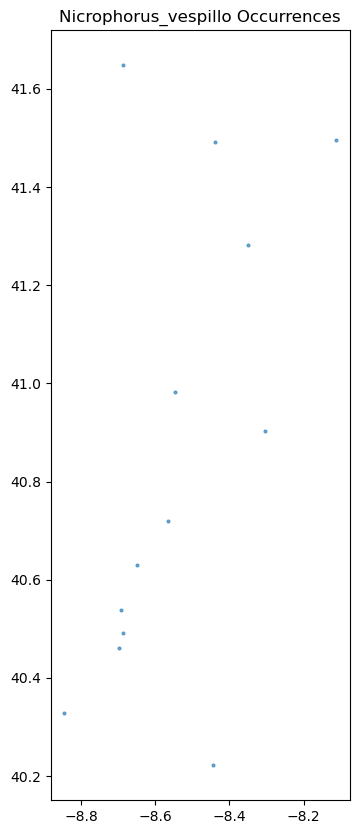

In [21]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    markersize=4,
    alpha=0.6
)

ax.set_title(f'{SPECIES} Occurrences')

plt.show()


## Output Paths

In [22]:
SPECIES_DIR = PROCESSED_SPECIES / SPECIES
SPECIES_DIR.mkdir(parents=True, exist_ok=True)

gpkg_path = SPECIES_DIR / f'{SPECIES}.gpkg'
geojson_path = SPECIES_DIR / f'{SPECIES}.geojson'
parquet_path = SPECIES_DIR / f'{SPECIES}.parquet'
csv_path = SPECIES_DIR / f'{SPECIES}.csv'

print(SPECIES_DIR)


/home/linda/Documents/myData/data-management/data/processed/species/Nicrophorus_vespillo


## Export GeoPackage

In [23]:
gdf_3035.to_file(
    gpkg_path,
    driver='GPKG'
)

print(gpkg_path)


/home/linda/Documents/myData/data-management/data/processed/species/Nicrophorus_vespillo/Nicrophorus_vespillo.gpkg


## Export GeoJSON

In [24]:
gdf.to_file(
    geojson_path,
    driver='GeoJSON'
)

print(geojson_path)


/home/linda/Documents/myData/data-management/data/processed/species/Nicrophorus_vespillo/Nicrophorus_vespillo.geojson


## Export GeoParquet

In [25]:
gdf.to_parquet(parquet_path)

print(parquet_path)


/home/linda/Documents/myData/data-management/data/processed/species/Nicrophorus_vespillo/Nicrophorus_vespillo.parquet


## Export CSV

In [26]:
gdf.drop(columns='geometry').to_csv(
    csv_path,
    index=False
)

print(csv_path)


/home/linda/Documents/myData/data-management/data/processed/species/Nicrophorus_vespillo/Nicrophorus_vespillo.csv


## QA Summary

In [27]:
print('FINAL SUMMARY')
print('-' * 40)

print(f'Species: {SPECIES}')
print(f'Records: {len(gdf)}')
print(f'CRS: {gdf.crs}')

print('\nOutputs:')
print(gpkg_path)
print(geojson_path)
print(parquet_path)
print(csv_path)


FINAL SUMMARY
----------------------------------------
Species: Nicrophorus_vespillo
Records: 13
CRS: EPSG:4326

Outputs:
/home/linda/Documents/myData/data-management/data/processed/species/Nicrophorus_vespillo/Nicrophorus_vespillo.gpkg
/home/linda/Documents/myData/data-management/data/processed/species/Nicrophorus_vespillo/Nicrophorus_vespillo.geojson
/home/linda/Documents/myData/data-management/data/processed/species/Nicrophorus_vespillo/Nicrophorus_vespillo.parquet
/home/linda/Documents/myData/data-management/data/processed/species/Nicrophorus_vespillo/Nicrophorus_vespillo.csv


## Interactive OpenStreetMap QA (manual validation)

In [28]:
review_gdf = gdf.copy()

center_lat = review_gdf['decimalLatitude'].mean()
center_lon = review_gdf['decimalLongitude'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=5,
    tiles='OpenStreetMap'
)

cluster = MarkerCluster().add_to(m)

for _, row in review_gdf.iterrows():

    popup = f"""
    <b>GBIF ID:</b> {row['gbifID']}<br>
    <b>Species:</b> {row['species']}<br>
    <b>Country:</b> {row['countryCode']}<br>
    <b>Date:</b> {row['eventDate']}<br>
    <b>Uncertainty:</b> {row['coordinateUncertaintyInMeters']}
    """

    folium.CircleMarker(
        location=[row['decimalLatitude'], row['decimalLongitude']],
        radius=4,
        color='red',
        fill=True,
        fill_opacity=0.6,
        popup=folium.Popup(popup, max_width=300)
    ).add_to(cluster)

display(m)

## Manual removal (cherry-pick bad records)

In [29]:
# Paste GBIF IDs you want to remove after inspecting the map
REMOVE_GBIF_IDS = [
    #5024499210,
   #3329219793,
]

REMOVE_GBIF_IDS = [str(x) for x in REMOVE_GBIF_IDS]

print("Before removal:", len(gdf))

Before removal: 13


In [30]:
removed_records = gdf[
    gdf['gbifID'].astype(str).isin(REMOVE_GBIF_IDS)
].copy()

print("Removed records:", len(removed_records))

if len(removed_records) > 0:
    removed_records.drop(columns='geometry').to_csv(
        removed_csv_path,
        index=False
    )
    print("Saved removed log:", removed_csv_path)

Removed records: 0


In [31]:
gdf = gdf[
    ~gdf['gbifID'].astype(str).isin(REMOVE_GBIF_IDS)
].copy()

print("Remaining records:", len(gdf))

Remaining records: 13


In [32]:
clean_center_lat = gdf['decimalLatitude'].mean()
clean_center_lon = gdf['decimalLongitude'].mean()

clean_map = folium.Map(
    location=[clean_center_lat, clean_center_lon],
    zoom_start=5,
    tiles='OpenStreetMap'
)

for _, row in gdf.iterrows():

    popup = f"""
    <b>GBIF ID:</b> {row['gbifID']}<br>
    <b>Species:</b> {row['species']}<br>
    <b>Country:</b> {row['countryCode']}
    """

    folium.CircleMarker(
        location=[row['decimalLatitude'], row['decimalLongitude']],
        radius=4,
        color='green',
        fill=True,
        fill_opacity=0.6,
        popup=popup
    ).add_to(clean_map)

display(clean_map)

In [33]:
clean_map.save(
    SPECIES_DIR / f'{SPECIES}_clean_map.html'
)

In [34]:
review_gdf.to_file(
    review_geojson_path,
    driver='GeoJSON'
)

print(review_geojson_path)

/home/linda/Documents/myData/data-management/data/qa/Nicrophorus_vespillo/Nicrophorus_vespillo_review_points.geojson


In [35]:
review_geojson_path

PosixPath('/home/linda/Documents/myData/data-management/data/qa/Nicrophorus_vespillo/Nicrophorus_vespillo_review_points.geojson')

In [37]:
# Update path 

import geopandas as gpd

path = "/home/linda/Documents/myData/data-management/data/qa/Nicrophorus_vespillo/Nicrophorus_vespillo_review_points.geojson"

gdf = gpd.read_file(path, engine="fiona")

gdf.head()

,gbifID,species,decimalLatitude,decimalLongitude,countryCode,eventDate,basisOfRecord,coordinateUncertaintyInMeters,year,month,day,geometry
0,6178503558,Nicrophorus vespillo,40.630628,-8.649583,PT,2026-03-16T12:34:01+00:00,HUMAN_OBSERVATION,NaN,2026,3,16,POINT (-8.64958 40.63063)
1,5827896471,Nicrophorus vespillo,41.495084,-8.112583,PT,2025-08-08T18:19:27,HUMAN_OBSERVATION,3361.0,2025,8,8,POINT (-8.11258 41.49508)
2,5230047378,Nicrophorus vespillo,40.490405,-8.686626,PT,2025-07-11T13:28:39,HUMAN_OBSERVATION,NaN,2025,7,11,POINT (-8.68663 40.4904)
3,5154723113,Nicrophorus vespillo,40.328999,-8.845453,PT,2024-09-14T17:17:39,HUMAN_OBSERVATION,NaN,2024,9,14,POINT (-8.84545 40.329)
4,4903933483,Nicrophorus vespillo,41.281934,-8.349700,PT,2024-07-01T23:27:48,HUMAN_OBSERVATION,6.0,2024,7,1,POINT (-8.3497 41.28193)


In [38]:
gdf["coordinateUncertaintyInMeters"].describe()

count       7.000000
mean      505.428571
std      1259.871403
min         4.000000
25%         7.000000
50%         8.000000
75%        75.500000
max      3361.000000
Name: coordinateUncertaintyInMeters, dtype: float64

In [39]:
gdf["coordinateUncertaintyInMeters"] = gdf["coordinateUncertaintyInMeters"].astype(float)

In [40]:
gdf_clean = gdf[gdf["coordinateUncertaintyInMeters"] <= 30].copy()

In [41]:
gdf_clean = gdf_clean.dropna(subset=["coordinateUncertaintyInMeters"])

In [42]:
print(len(gdf), "original records")
print(len(gdf_clean), "after cleaning")

13 original records
4 after cleaning


In [44]:
# Update path & layer name here

gpkg_path = "/home/linda/Documents/myData/data-management/data/processed/species/Nicrophorus_vespillo/Nicrophorus_vespillo_clean.gpkg"

gdf_clean.to_file(
    gpkg_path,
    layer="spp_clean",
    driver="GPKG"
)

print(gpkg_path)

/home/linda/Documents/myData/data-management/data/processed/species/Nicrophorus_vespillo/Nicrophorus_vespillo_clean.gpkg
